## Reduced Feature Analysis 
In this notebook, we analyse the difference in performance of the balanced Random Forest Classifier model on all 3 datasets for different variations of features.

In [27]:
# All imports needed for this experiment

import pandas as pd
import os
import joblib

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import  StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [28]:
# Load the aligned datasets
df1 = pd.read_csv("../data/aligned/dataset_1_aligned.csv")
df2 = pd.read_csv("../data/aligned/dataset_2_aligned.csv")
df3 = pd.read_csv("../data/aligned/dataset_3_aligned.csv")


In [29]:
# Rename the target column to 'target' for consistency
df1 = df1.rename(columns={'Class':'target'})
df1.head(5)

,Unnamed: 0,bp,sg,al,su,rbc,bu,sc,sod,pot,hemo,wc,rc,htn,target
0,0,80.0,1.020,1.0,0.0,NaN,36.0,1.2,NaN,NaN,15.4,7800,5.2,yes,1
1,1,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3,6000,NaN,no,1
2,2,80.0,1.010,2.0,3.0,normal,53.0,1.8,NaN,NaN,9.6,7500,NaN,no,1
3,3,70.0,1.005,4.0,0.0,normal,56.0,3.8,111.0,2.5,11.2,6700,3.9,yes,1
4,4,80.0,1.010,2.0,0.0,normal,26.0,1.4,NaN,NaN,11.6,7300,4.6,no,1


In [30]:
# Rename the target column to 'target' for consistency
df2 = df2.rename(columns={'Class':'target'})
df2.head(5)

,Unnamed: 0,bp,sg,al,su,rbc,bu,sc,sod,pot,hemo,wc,rc,htn,target
0,0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1


In [31]:
df3.head(5)

,Unnamed: 0,bp,sg,al,su,rbc,bu,sc,sod,pot,hemo,wc,rc,htn,target
0,0,167,1.023,1,4,normal,169.101369,7.55,146.068410,6.272576,11.8,5791,5.6,yes,0
1,1,127,1.023,3,2,normal,183.223479,13.37,123.501427,5.611303,8.2,5390,4.6,no,1
2,2,148,1.016,0,0,abnormal,193.141665,9.49,149.456527,3.965957,10.1,12098,4.7,no,0
3,3,98,1.017,4,0,abnormal,125.939396,10.98,131.758843,4.980997,14.0,6747,4.8,no,0
4,4,174,1.015,1,1,normal,197.188600,3.01,120.912465,4.097602,16.1,5759,5.7,no,0


In [32]:
# Function to train and evaluate a model on a given subset of features
def evaluate_feature_subset(df, selected_features, random_state=42):

    X = df[selected_features]
    y = df["target"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

    numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    X_train_t = preprocessor.fit_transform(X_train)
    X_test_t = preprocessor.transform(X_test)

    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_t, y_train)

    model = RandomForestClassifier(class_weight="balanced",
        random_state=random_state)
    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_t)
    y_prob = model.predict_proba(X_test_t)[:, 1]

    return {
        "n_features": len(selected_features),
        "features": selected_features,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }


In [33]:
# Different combinations of features to evaluate

# Top N features based on feature importance
top_5 = ['hemo', 'sc', 'sg', 'rc', 'al']
top_10 = ['hemo', 'sc', 'sg', 'rc', 'al', 'htn', 'bu', 'sod', 'bp', 'su']

# Bottom N features based on feature importance
bottom_5 = ['bp', 'su', 'pot', 'wc', 'rbc']
bottom_10 = ['rc', 'al', 'htn', 'bu', 'sod', 'bp', 'su', 'pot', 'wc', 'rbc']

# All features
all_features = ['hemo', 'sc', 'sg', 'rc', 'al', 'htn', 'bu', 'sod', 'bp', 'su', 'pot', 'wc', 'rbc']

# Drop one feature at a time
drop_hemo = ['sc', 'sg', 'rc', 'al', 'htn', 'bu', 'sod', 'bp', 'su', 'pot', 'wc', 'rbc']
drop_sc = ['hemo', 'sg', 'rc', 'al', 'htn', 'bu', 'sod', 'bp', 'su', 'pot', 'wc', 'rbc']
drop_sg = ['hemo', 'sc', 'rc', 'al', 'htn', 'bu', 'sod', 'bp', 'su', 'pot', 'wc', 'rbc']

# Random subsets of features
random_5 = ['bp', 'wc', 'pot', 'rbc', 'sod']
random_7 = ['su', 'wc', 'pot', 'bp', 'rbc', 'sod', 'htn']

# Add one feature at a time based on importance
f1 = ['hemo']
f2 = ['hemo', 'sc']
f3 = ['hemo', 'sc', 'sg']
f4 = ['hemo', 'sc', 'sg', 'rc']

In [34]:
# Dataset 1 - Evaluate all feature subsets

results = []

# Top N features based on feature importance
results.append(evaluate_feature_subset(df1, top_5, random_state=42))
results.append(evaluate_feature_subset(df1, top_10, random_state=42))

# All features
results.append(evaluate_feature_subset(df1, all_features, random_state=42))

# Bottom N features based on feature importance
results.append(evaluate_feature_subset(df1, bottom_5, random_state=42))
results.append(evaluate_feature_subset(df1, bottom_10, random_state=42))

# Drop one feature at a time
results.append(evaluate_feature_subset(df1, drop_hemo, random_state=42))
results.append(evaluate_feature_subset(df1, drop_sc, random_state=42))
results.append(evaluate_feature_subset(df1, drop_sg, random_state=42))

# Random subsets of features
results.append(evaluate_feature_subset(df1, random_5, random_state=42))
results.append(evaluate_feature_subset(df1, random_7, random_state=42))

# Add one feature at a time based on importance
results.append(evaluate_feature_subset(df1, f1, random_state=42))
results.append(evaluate_feature_subset(df1, f2, random_state=42))
results.append(evaluate_feature_subset(df1, f3, random_state=42))
results.append(evaluate_feature_subset(df1, f4, random_state=42))

results_df = pd.DataFrame(results)
results_df

/var/folders/s1/z7ywf1314wggd5t1h2rl_t7w0000gn/T/ipykernel_34621/1751528841.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
/var/folders/s1/z7ywf1314wggd5t1h2rl_t7w0000gn/T/ipykernel_34621/1751528841.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence t

,n_features,features,accuracy,precision,recall,f1,roc_auc
0,5,"[hemo, sc, sg, rc, al]",1.0000,1.000000,1.00,1.000000,1.000000
1,10,"[hemo, sc, sg, rc, al, htn, bu, sod, bp, su]",1.0000,1.000000,1.00,1.000000,1.000000
2,13,"[hemo, sc, sg, rc, al, htn, bu, sod, bp, su, p...",1.0000,1.000000,1.00,1.000000,1.000000
3,5,"[bp, su, pot, wc, rbc]",0.8375,0.877551,0.86,0.868687,0.907333
4,10,"[rc, al, htn, bu, sod, bp, su, pot, wc, rbc]",0.9625,0.960784,0.98,0.970297,0.996000
5,12,"[sc, sg, rc, al, htn, bu, sod, bp, su, pot, wc...",1.0000,1.000000,1.00,1.000000,1.000000
6,12,"[hemo, sg, rc, al, htn, bu, sod, bp, su, pot, ...",0.9875,0.980392,1.00,0.990099,1.000000
7,12,"[hemo, sc, rc, al, htn, bu, sod, bp, su, pot, ...",1.0000,1.000000,1.00,1.000000,1.000000
8,5,"[bp, wc, pot, rbc, sod]",0.9125,0.957447,0.90,0.927835,0.941000
9,7,"[su, wc, pot, bp, rbc, sod, htn]",0.9750,0.980000,0.98,0.980000,0.988667


*Insights*

The results show that a small group of key features consistently drives the model’s performance, as even using just a few top features produces near-perfect results. In particular, **hemoglobin** appears to be especially important, since strong performance is achieved even when it is used alone or in small combinations. Adding more features does not improve performance, suggesting that most of the important information is already captured early on. In contrast, using less important or random features leads to noticeable drops in performance, confirming that not all features contribute equally.

In [35]:
# Dataset 2 - Evaluate all feature subsets

results = []

# Top N features based on feature importance
results.append(evaluate_feature_subset(df2, top_5, random_state=42))
results.append(evaluate_feature_subset(df2, top_10, random_state=42))

# All features
results.append(evaluate_feature_subset(df2, all_features, random_state=42))

# Bottom N features based on feature importance
results.append(evaluate_feature_subset(df2, bottom_5, random_state=42))
results.append(evaluate_feature_subset(df2, bottom_10, random_state=42))

# Drop one feature at a time
results.append(evaluate_feature_subset(df2, drop_hemo, random_state=42))
results.append(evaluate_feature_subset(df2, drop_sc, random_state=42))
results.append(evaluate_feature_subset(df2, drop_sg, random_state=42))

# Random subsets of features
results.append(evaluate_feature_subset(df2, random_5, random_state=42))
results.append(evaluate_feature_subset(df2, random_7, random_state=42))

# Add one feature at a time based on importance
results.append(evaluate_feature_subset(df2, f1, random_state=42))
results.append(evaluate_feature_subset(df2, f2, random_state=42))
results.append(evaluate_feature_subset(df2, f3, random_state=42))
results.append(evaluate_feature_subset(df2, f4, random_state=42))

results_df2 = pd.DataFrame(results)
results_df2

,n_features,features,accuracy,precision,recall,f1,roc_auc
0,5,"[hemo, sc, sg, rc, al]",1.0000,1.000000,1.00,1.000000,1.000000
1,10,"[hemo, sc, sg, rc, al, htn, bu, sod, bp, su]",1.0000,1.000000,1.00,1.000000,1.000000
2,13,"[hemo, sc, sg, rc, al, htn, bu, sod, bp, su, p...",1.0000,1.000000,1.00,1.000000,1.000000
3,5,"[bp, su, pot, wc, rbc]",0.8625,0.914894,0.86,0.886598,0.927667
4,10,"[rc, al, htn, bu, sod, bp, su, pot, wc, rbc]",0.9625,0.979592,0.96,0.969697,0.987667
5,12,"[sc, sg, rc, al, htn, bu, sod, bp, su, pot, wc...",1.0000,1.000000,1.00,1.000000,1.000000
6,12,"[hemo, sg, rc, al, htn, bu, sod, bp, su, pot, ...",1.0000,1.000000,1.00,1.000000,1.000000
7,12,"[hemo, sc, rc, al, htn, bu, sod, bp, su, pot, ...",0.9750,1.000000,0.96,0.979592,0.994333
8,5,"[bp, wc, pot, rbc, sod]",0.8875,0.936170,0.88,0.907216,0.963333
9,7,"[su, wc, pot, bp, rbc, sod, htn]",0.9250,0.958333,0.92,0.938776,0.987667


*Insights*

The results show a similar pattern to **Dataset 1**, where a small set of key features is enough to achieve very high performance. **Hemoglobin** again stands out as an important feature, as strong results are achieved even when it is used alone or combined with just a few others. Adding more features does not significantly improve performance, indicating that the main predictive information is captured by the top features. In contrast, using lower-ranked or random features leads to reduced performance, confirming that the most important features drive the model’s success.

In [36]:
# Dataset 3 - Evaluate all feature subsets

results = []

# Top N features based on feature importance
results.append(evaluate_feature_subset(df3, top_5, random_state=42))
results.append(evaluate_feature_subset(df3, top_10, random_state=42))

# All features
results.append(evaluate_feature_subset(df3, all_features, random_state=42))

# Bottom N features based on feature importance
results.append(evaluate_feature_subset(df3, bottom_5, random_state=42))
results.append(evaluate_feature_subset(df3, bottom_10, random_state=42))

# Drop one feature at a time
results.append(evaluate_feature_subset(df3, drop_hemo, random_state=42))
results.append(evaluate_feature_subset(df3, drop_sc, random_state=42))
results.append(evaluate_feature_subset(df3, drop_sg, random_state=42))

# Random subsets of features
results.append(evaluate_feature_subset(df3, random_5, random_state=42))
results.append(evaluate_feature_subset(df3, random_7, random_state=42))

# Add one feature at a time based on importance
results.append(evaluate_feature_subset(df3, f1, random_state=42))
results.append(evaluate_feature_subset(df3, f2, random_state=42))
results.append(evaluate_feature_subset(df3, f3, random_state=42))
results.append(evaluate_feature_subset(df3, f4, random_state=42))

results_df3 = pd.DataFrame(results)
results_df3

/var/folders/s1/z7ywf1314wggd5t1h2rl_t7w0000gn/T/ipykernel_34621/1751528841.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
/var/folders/s1/z7ywf1314wggd5t1h2rl_t7w0000gn/T/ipykernel_34621/1751528841.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence t

,n_features,features,accuracy,precision,recall,f1,roc_auc
0,5,"[hemo, sc, sg, rc, al]",0.755842,0.165441,0.054811,0.082342,0.495854
1,10,"[hemo, sc, sg, rc, al, htn, bu, sod, bp, su]",0.794791,0.288462,0.018270,0.034364,0.508396
2,13,"[hemo, sc, sg, rc, al, htn, bu, sod, bp, su, p...",0.792356,0.166667,0.009744,0.018412,0.495260
3,5,"[bp, su, pot, wc, rbc]",0.672833,0.209121,0.228989,0.218605,0.503035
4,10,"[rc, al, htn, bu, sod, bp, su, pot, wc, rbc]",0.789679,0.234568,0.023143,0.042129,0.511743
5,12,"[sc, sg, rc, al, htn, bu, sod, bp, su, pot, wc...",0.794304,0.184211,0.008526,0.016298,0.474938
6,12,"[hemo, sg, rc, al, htn, bu, sod, bp, su, pot, ...",0.796008,0.292683,0.014616,0.027842,0.495746
7,12,"[hemo, sc, rc, al, htn, bu, sod, bp, su, pot, ...",0.789679,0.240964,0.024361,0.044248,0.508637
8,5,"[bp, wc, pot, rbc, sod]",0.686222,0.214634,0.214373,0.214503,0.508856
9,7,"[su, wc, pot, bp, rbc, sod, htn]",0.736611,0.216920,0.121803,0.156006,0.499077


Unlike the previous datasets, performance remains low across all feature combinations, even when using the most important features. While **hemoglobin** still shows some influence when used alone or in small groups, it is not enough to achieve strong results. This is largely due to the significant class imbalance in **Dataset 3**, where the model struggles to correctly identify the minority class. As a result, the model tends to favour the majority class, leading to poor overall predictive performance.

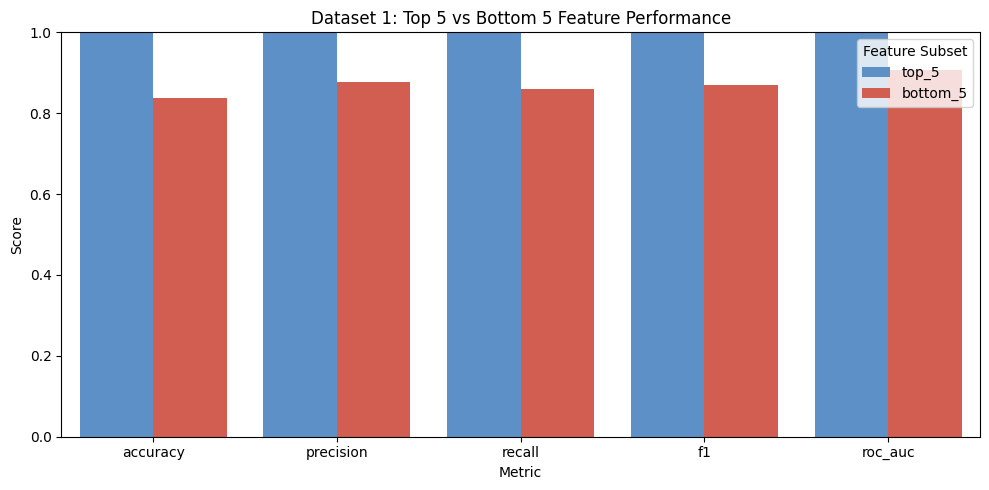

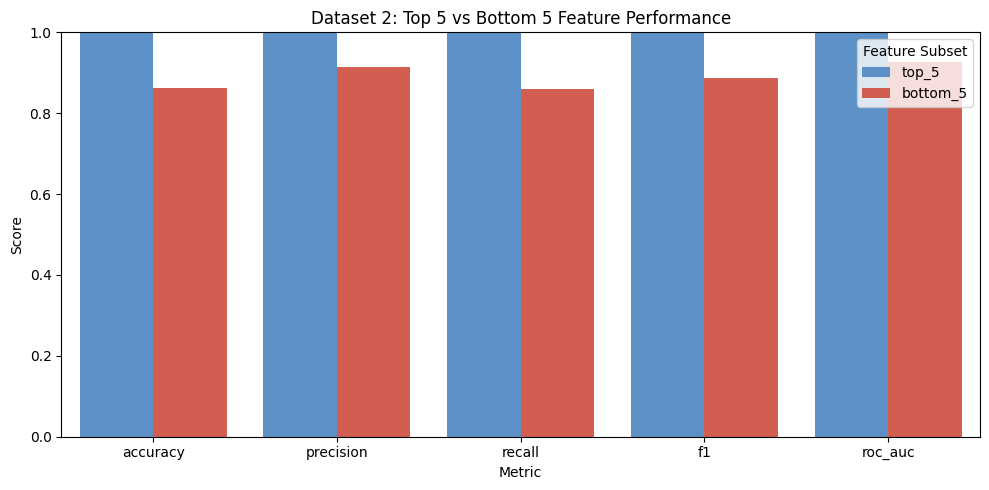

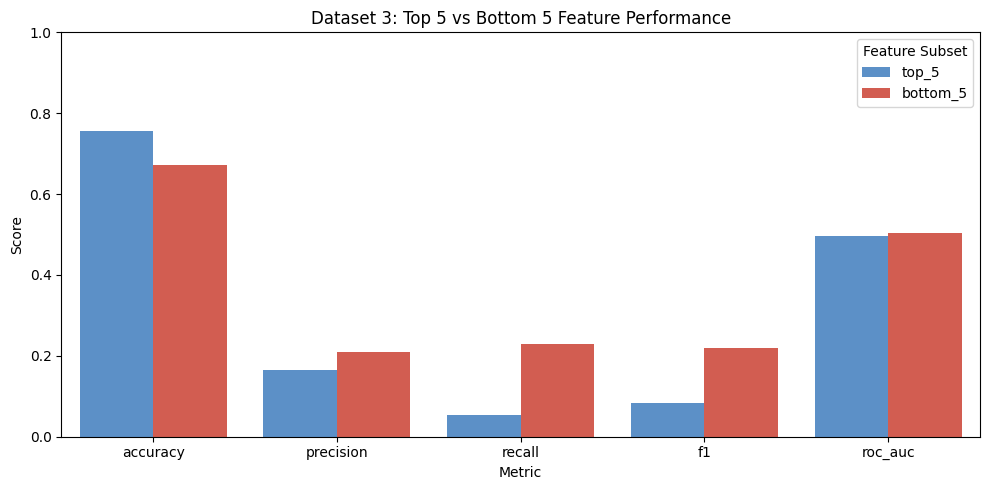

In [45]:
metric_columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]


def plot_top_bottom_metrics(results_df, dataset_name):
    comparison_df = results_df[results_df["features"].apply(lambda subset: subset in [top_5, bottom_5])].copy()
    comparison_df["subset"] = comparison_df["features"].apply(
        lambda subset: "top_5" if subset == top_5 else "bottom_5"
    )

    melted_df = comparison_df.melt(
        id_vars="subset",
        value_vars=metric_columns,
        var_name="metric",
        value_name="score",
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=melted_df,
        x="metric",
        y="score",
        hue="subset",
        palette=['#4A90D9', '#E74C3C'],
    )

    plt.title(f"{dataset_name}: Top 5 vs Bottom 5 Feature Performance")
    plt.ylabel("Score")
    plt.xlabel("Metric")
    plt.ylim(0, 1)
    plt.legend(title="Feature Subset")
    plt.tight_layout()
    plt.show()


plot_top_bottom_metrics(results_df, "Dataset 1")
plot_top_bottom_metrics(results_df2, "Dataset 2")
plot_top_bottom_metrics(results_df3, "Dataset 3")